# Statistik mit Python

**Einführung anhand von Messdaten eines Web-Systems**

In diesem Notebook werden grundlegende Verfahren der deskriptiven Statistik mit Python angewendet. Python dient zur Aufbereitung, Auswertung und grafischen Darstellung der Daten.

## Lernziele

Nach der Bearbeitung des Notebooks können Sie

- die Vektor- und Summennotation aus Vorlesung 0 in einfachen Python-Ausdrücken wiedererkennen,
- Grundgesamtheit, Merkmale, Ausprägungen und Wertemengen an einem Datensatz erläutern,
- nominal, ordinal und metrisch skalierte Merkmale sowie diskrete und stetige Merkmale unterscheiden,
- Daten auswählen, filtern und gruppieren,
- absolute und relative Häufigkeiten sowie einen Modalwert bestimmen,
- arithmetisches Mittel, Median, unteres und oberes Quartil, Interquartilsabstand und empirische Standardabweichung berechnen und interpretieren,
- Säulendiagramm, Histogramm, Boxplot und Streudiagramm sachgerecht einsetzen,
- den Pearson-Korrelationskoeffizienten interpretieren,
- deskriptive Aussagen von kausalen Aussagen unterscheiden und
- die zufällige Schwankung von Stichprobenmittelwerten erläutern.

Eine Code-Zelle wird mit **Shift + Enter** ausgeführt.

## Fragestellungen

Wir betrachten Messdaten eines fiktiven Web-Systems. Jede Zeile des Datensatzes beschreibt einen API-Request.

1. Welche Endpoints werden häufig aufgerufen?
2. Wie unterscheiden sich die Antwortzeiten zwischen den Endpoints?
3. Wie sind die Antwortzeiten verteilt und wie stark streuen sie?
4. Besteht ein linearer Zusammenhang zwischen Payload-Größe und Antwortzeit?
5. Unterscheiden sich die Antwortzeiten bei Requests mit und ohne Cache-Hit?
6. Wie stark schwankt das arithmetische Mittel zwischen verschiedenen Zufallsstichproben?

## 1. Anknüpfung an Vorlesung 0

In Vorlesung 0 wurden Vektoren und das Summenzeichen eingeführt. Ein Vektor wird dort in der Form

\[
x=(x_1,x_2,\ldots,x_n)
\]

geschrieben. Die Reihenfolge der Elemente ist dabei wesentlich; Werte dürfen mehrfach auftreten.

Wir verwenden den Vektor

\[
x=(3,-4,11,-1,6).
\]

Die Werte eines solchen Vektors können in Python beispielsweise in einer Liste gespeichert werden.

In [1]:
x = [3, -4, 11, -1, 6]

print("Anzahl der Elemente n:", len(x))
print("Erstes Element x_1:", x[0])
print("Summe der Elemente:", sum(x))

Anzahl der Elemente n: 5
Erstes Element x_1: 3
Summe der Elemente: 15


Python beginnt bei der Nummerierung von Listenelementen mit `0`. Daher entspricht `x[0]` dem mathematischen Element \(x_1\).

Auch Summen lassen sich unmittelbar berechnen. Zum Beispiel entsprechen die folgenden Python-Ausdrücke den Summen

\[
\sum_{i=1}^n x_i,\qquad
\sum_{i=1}^n x_i^2,\qquad
\sum_{i=1}^n (x_i-3)^2.
\]

Die genaue Python-Syntax ist an dieser Stelle nicht das Lernziel. Entscheidend ist die Verbindung zwischen mathematischer Schreibweise und Berechnung.

In [2]:
print("Summe x_i:       ", sum(xi for xi in x))
print("Summe x_i^2:     ", sum(xi**2 for xi in x))
print("Summe (x_i-3)^2: ", sum((xi - 3)**2 for xi in x))

Summe x_i:        15
Summe x_i^2:      183
Summe (x_i-3)^2:  138


## 2. Untersuchungsgegenstand und Merkmale

Ein **API-Request** ist eine Anfrage eines Programms an einen Server. Ein **Endpoint** bezeichnet die angesprochene Funktion der Schnittstelle, beispielsweise `/search` oder `/checkout`. Die **Payload** ist die übertragene Datenmenge. Ein **Cache** ist ein Zwischenspeicher; bei einem **Cache-Hit** können bereits gespeicherte Daten verwendet werden.

Die Variablen im Datensatz haben folgende Bedeutung:

| Variable | Bedeutung |
|---|---|
| `request_id` | Kennung des Requests |
| `endpoint` | angesprochener API-Endpoint |
| `region` | Region des Requests |
| `hour` | Stunde des Tages |
| `cache_hit` | gibt an, ob Daten aus dem Cache verwendet wurden |
| `payload_kb` | Payload-Größe in Kilobyte |
| `response_ms` | Antwortzeit in Millisekunden |
| `status_code` | HTTP-Statuscode, z. B. 200, 404 oder 500 |

### Grundgesamtheit, Merkmale und Ausprägungen

Die **Grundgesamtheit** umfasst die für eine Untersuchung interessanten Daten liefernden Objekte. In unserem Beispiel können – abhängig von der Fragestellung – alle API-Requests des betrachteten Web-Systems als Grundgesamtheit aufgefasst werden.

Ein **Merkmal** ist eine für die Untersuchung interessante Eigenschaft eines solchen Objekts, beispielsweise der Endpoint oder die Antwortzeit.

Eine **Ausprägung** ist ein möglicher Wert eines Merkmals. Die **Wertemenge** \(W\) enthält alle möglichen Ausprägungen eines Merkmals.

Beispiele:

\[
W_{\mathrm{cache}}=\{\mathrm{False},\mathrm{True}\}
\]

und

\[
W_{\mathrm{endpoint}}=
\{\mathrm{/login},\mathrm{/search},\mathrm{/product},\mathrm{/cart},\mathrm{/checkout}\}.
\]

Die 320 Zeilen sind die vorliegenden Beobachtungen. Werden sie als Teil einer größeren Grundgesamtheit betrachtet, bilden sie eine **Stichprobe**.

### Merkmalsskalierungen sowie diskrete und stetige Merkmale

In der Vorlesung werden nominal, ordinal und metrisch skalierte Merkmale unterschieden. Zusätzlich wird betrachtet, ob ein Merkmal diskret oder stetig modelliert wird.

| Merkmal | Skalierung | Modellierung |
|---|---|---|
| `request_id` | nominal | diskret |
| `endpoint` | nominal | diskret |
| `region` | nominal | diskret |
| `cache_hit` | nominal | diskret |
| `status_code` | nominal | diskret |
| `hour` | metrisch und ordinal | diskret |
| `payload_kb` | metrisch und ordinal | quasi-stetig |
| `response_ms` | metrisch und ordinal | quasi-stetig |

`status_code` ist trotz der Zahlencodierung nominalskaliert. Mit den Zahlenwerten 200, 404 und 500 kann nicht im Sinne eines metrischen Merkmals gerechnet werden.

`payload_kb` und `response_ms` werden im Datensatz gerundet gespeichert. Wegen der großen Zahl möglicher Werte werden sie hier zweckmäßig als quasi-stetige Merkmale behandelt.

`hour` wird in ganzen Stunden erfasst. Da es sich um eine Uhrzeit und nicht um eine Zeitdauer handelt, verwenden wir dieses Merkmal im Folgenden nicht für Lage- oder Streuungsmaße.

## 3. Benötigte Python-Bibliotheken

Wir verwenden `pandas` zur Arbeit mit Tabellen, `numpy` für numerische Berechnungen und Zufallszahlen sowie `matplotlib` für grafische Darstellungen.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (8, 4.5)

## 4. Datensatz einlesen und prüfen

In [4]:
df = pd.read_csv("data/api_requests.csv")
df.head()

,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
0,REQ-0001,/login,US-East,10,False,10.4,236.0,200
1,REQ-0002,/checkout,EU-West,17,False,18.5,272.5,500
2,REQ-0003,/checkout,US-East,8,False,14.3,387.5,200
3,REQ-0004,/search,EU-West,19,False,41.5,216.7,200
4,REQ-0005,/cart,EU-West,9,False,16.6,180.1,200


In [5]:
print("Anzahl Zeilen und Spalten:", df.shape)
print("Spalten:", df.columns.to_list())

Anzahl Zeilen und Spalten: (320, 8)
Spalten: ['request_id', 'endpoint', 'region', 'hour', 'cache_hit', 'payload_kb', 'response_ms', 'status_code']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   request_id   320 non-null    object 
 1   endpoint     320 non-null    object 
 2   region       320 non-null    object 
 3   hour         320 non-null    int64  
 4   cache_hit    320 non-null    bool   
 5   payload_kb   320 non-null    float64
 6   response_ms  314 non-null    float64
 7   status_code  320 non-null    int64  
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 17.9+ KB


Vor einer statistischen Auswertung sollte geprüft werden, ob Werte fehlen. Fehlende Werte werden nicht pauschal entfernt. Für jede Auswertung ist zu entscheiden, welche Variablen benötigt werden.

In [7]:
df.isna().sum()

request_id     0
endpoint       0
region         0
hour           0
cache_hit      0
payload_kb     0
response_ms    6
status_code    0
dtype: int64

Für Auswertungen der Antwortzeit benötigen wir Beobachtungen mit vorhandenem Wert von `response_ms`. Dafür wird ein eigener DataFrame angelegt. Bei Auswertungen anderer Merkmale kann weiterhin der vollständige Datensatz verwendet werden.

In einer realen Untersuchung müsste zusätzlich geklärt werden, weshalb Werte fehlen. Das Entfernen unvollständiger Beobachtungen kann zu Verzerrungen führen, wenn das Auftreten fehlender Werte systematisch ist.

In [8]:
response_data = df.dropna(subset=["response_ms"]).copy()

print("Alle Requests:", len(df))
print("Requests mit gemessener Antwortzeit:", len(response_data))

Alle Requests: 320
Requests mit gemessener Antwortzeit: 314


## 5. Daten auswählen und filtern

Mit Bedingungen lassen sich Teilmengen eines DataFrames auswählen.

In [9]:
# Eine Spalte auswählen
response_data["response_ms"].head()

0    236.0
1    272.5
2    387.5
3    216.7
4    180.1
Name: response_ms, dtype: float64

In [10]:
# Requests mit HTTP-Statuscode 500
server_errors = df[df["status_code"] == 500]
server_errors[["request_id", "endpoint", "response_ms", "status_code"]].head()

,request_id,endpoint,response_ms,status_code
1,REQ-0002,/checkout,272.5,500
11,REQ-0012,/product,219.6,500
36,REQ-0037,/cart,272.8,500
44,REQ-0045,/product,121.5,500
67,REQ-0068,/product,240.8,500


In [11]:
# Mehrere Bedingungen verknüpfen
slow_checkout = response_data[
    (response_data["endpoint"] == "/checkout")
    & (response_data["response_ms"] > 400)
]

slow_checkout.head()

,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
78,REQ-0079,/checkout,US-East,11,False,26.1,410.1,200
107,REQ-0108,/checkout,US-East,10,False,15.5,443.8,200
222,REQ-0223,/checkout,US-East,17,False,14.5,400.6,200
231,REQ-0232,/checkout,US-East,11,False,22.6,415.0,200
314,REQ-0315,/checkout,US-East,20,False,18.2,413.8,500


### Übung 1: Filtern

Filtern Sie alle Requests, die

- den Endpoint `/search` verwenden,
- aus `EU-Central` stammen und
- eine Antwortzeit von mehr als 250 ms haben.

Bestimmen Sie die Anzahl dieser Requests.

Überlegen Sie anschließend: Welche Aussage beschreibt nur die vorliegenden Beobachtungen, und welche Aussage wäre bereits eine Verallgemeinerung auf die Grundgesamtheit?

In [12]:
search_eu_slow = response_data[
    (response_data["endpoint"] == "/search")
    & (response_data["region"] == "EU-Central")
    & (response_data["response_ms"] > 250)
]

print("Anzahl:", len(search_eu_slow))
search_eu_slow.head()

Anzahl: 2


,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
72,REQ-0073,/search,EU-Central,10,True,119.6,251.1,200
276,REQ-0277,/search,EU-Central,16,False,47.0,280.9,200


Die berechnete Anzahl beschreibt die vorliegenden Beobachtungen. Eine Aussage über alle zukünftigen Requests wäre eine induktive Schlussfolgerung und setzt geeignete Annahmen über die Datenerhebung voraus.

## 6. Häufigkeiten für ein diskretes Merkmal

Der Endpoint ist ein nominalskaliertes und damit diskretes Merkmal.

Für eine Ausprägung \(w\in W\) bezeichnet

- \(H(w)\) die **absolute Häufigkeit** und
- \(h(w)=H(w)/n\) die **relative Häufigkeit**.

Der häufigste Wert der Wertemenge heißt **Modalwert**. Es können mehrere Modalwerte auftreten.

Für die Frage nach der Häufigkeitsverteilung der Endpoints werden alle Requests betrachtet. Fehlende Antwortzeiten spielen für diese Auswertung keine Rolle.

In [13]:
# Absolute Häufigkeiten
endpoint_counts = df["endpoint"].value_counts()
endpoint_counts

endpoint
/search      91
/product     78
/cart        54
/login       53
/checkout    44
Name: count, dtype: int64

In [14]:
# Relative Häufigkeiten in Prozent
endpoint_percent = df["endpoint"].value_counts(normalize=True) * 100
endpoint_percent.round(1)

endpoint
/search      28.4
/product     24.4
/cart        16.9
/login       16.6
/checkout    13.8
Name: proportion, dtype: float64

In [15]:
print("Modalwert:", df["endpoint"].mode().tolist())

Modalwert: ['/search']


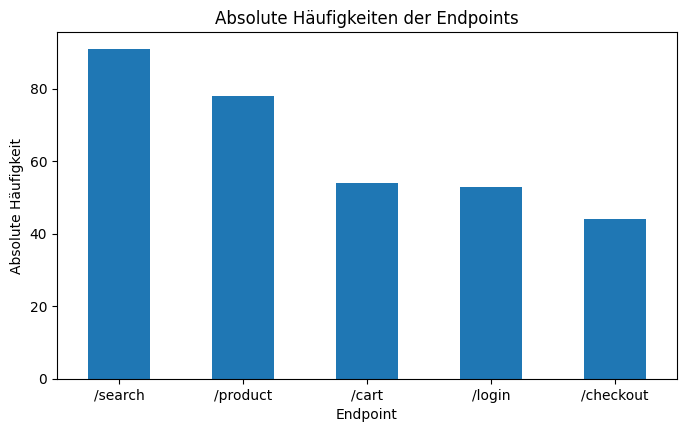

In [16]:
endpoint_counts.plot(kind="bar")
plt.title("Absolute Häufigkeiten der Endpoints")
plt.xlabel("Endpoint")
plt.ylabel("Absolute Häufigkeit")
plt.xticks(rotation=0)
plt.show()

Für nominalskalierte Merkmale sind Häufigkeitstabellen und Säulendiagramme geeignete Darstellungen. Ein Histogramm wird dagegen zur Darstellung der Verteilung eines metrisch skalierten Merkmals verwendet.

## 7. Metrisch skalierte Merkmale: Lage und Streuung

Für die Antwortzeit betrachten wir verschiedene Lage- und Streuungsmaße.

Das arithmetische Mittel eines Datenvektors \(x=(x_1,\ldots,x_n)\) ist

\[
\bar{x}=\frac{1}{n}\sum_{i=1}^n x_i.
\]

Damit erscheint das Summenzeichen aus Vorlesung 0 unmittelbar wieder.

In [17]:
response_data["response_ms"].agg(
    ["count", "mean", "median", "std", "min", "max"]
).round(1)

count      314.0
mean       223.9
median     196.2
std        144.0
min         28.0
max       1161.6
Name: response_ms, dtype: float64

### Quantile und Quartile

Für Quantile sind verschiedene Festlegungen möglich. In der Vorlesung wird für Datenvektoren metrischer Merkmale folgende Quantilformel verwendet.

Es sei \(k=\alpha n\).

- Ist \(k\) keine ganze Zahl, gilt \(q_x(\alpha)=x_{(\lceil k\rceil)}\).
- Ist \(k\) ganzzahlig, gilt
  \[
  q_x(\alpha)=\frac{x_{(k)}+x_{(k+1)}}{2}.
  \]

Dabei bezeichnet \(x_{(i)}\) die \(i\)-te Beobachtung der aufsteigend geordneten Daten.

Die Quantile

\[
q_x(0{,}25)\quad\text{und}\quad q_x(0{,}75)
\]

heißen **unteres Quartil** und **oberes Quartil**. Ihre Differenz

\[
IQR_x=q_x(0{,}75)-q_x(0{,}25)
\]

heißt **Interquartilsabstand**.

Damit die Berechnung in Python mit der Quantilformel der Vorlesung übereinstimmt, verwenden wir eine eigene Funktion.

In [18]:
def empirisches_quantil(values, alpha):
    if not 0 < alpha < 1:
        raise ValueError("alpha muss zwischen 0 und 1 liegen.")

    ordered = np.sort(np.asarray(values))
    n = len(ordered)
    k = alpha * n

    if np.isclose(k, round(k)):
        k = int(round(k))
        return (ordered[k - 1] + ordered[k]) / 2

    k = int(np.ceil(k))
    return ordered[k - 1]


def boxplot_statistik(values, label=""):
    """Kennwerte für einen Boxplot nach der Quantildefinition der Vorlesung."""
    ordered = np.sort(pd.Series(values).dropna().to_numpy())

    q_unten = empirisches_quantil(ordered, 0.25)
    median = np.median(ordered)
    q_oben = empirisches_quantil(ordered, 0.75)
    iqr = q_oben - q_unten

    untere_grenze = q_unten - 1.5 * iqr
    obere_grenze = q_oben + 1.5 * iqr

    keine_ausreisser = ordered[(ordered >= untere_grenze) & (ordered <= obere_grenze)]
    ausreisser = ordered[(ordered < untere_grenze) | (ordered > obere_grenze)]

    return {
        "label": label,
        "whislo": keine_ausreisser.min(),
        "q1": q_unten,
        "med": median,
        "q3": q_oben,
        "whishi": keine_ausreisser.max(),
        "fliers": ausreisser.tolist(),
    }

In [19]:
response_times = response_data["response_ms"]

q_unten = empirisches_quantil(response_times, 0.25)
q_oben = empirisches_quantil(response_times, 0.75)
iqr = q_oben - q_unten

print("Arithmetisches Mittel:          ", round(response_times.mean(), 1), "ms")
print("Median:                         ", round(response_times.median(), 1), "ms")
print("Empirische Standardabweichung: ", round(response_times.std(), 1), "ms")
print("Unteres Quartil q_x(0,25):     ", round(q_unten, 1), "ms")
print("Oberes Quartil q_x(0,75):      ", round(q_oben, 1), "ms")
print("Interquartilsabstand IQR_x:     ", round(iqr, 1), "ms")

Arithmetisches Mittel:           223.9 ms
Median:                          196.2 ms
Empirische Standardabweichung:  144.0 ms
Unteres Quartil q_x(0,25):      156.5 ms
Oberes Quartil q_x(0,75):       252.3 ms
Interquartilsabstand IQR_x:      95.8 ms


`pandas.Series.std()` verwendet standardmäßig den Divisor \(n-1\). Damit entspricht die ausgegebene Standardabweichung der in der Vorlesung verwendeten empirischen Standardabweichung.

### Arithmetisches Mittel und Median

Das **arithmetische Mittel** berücksichtigt alle beobachteten Werte und reagiert deshalb empfindlich auf sehr große oder sehr kleine Beobachtungen.

Der **Median** ist ein Lagemaß auf Grundlage der geordneten Beobachtungen. Bei ungeradem Stichprobenumfang ist er die mittlere Beobachtung; bei geradem Stichprobenumfang wird das arithmetische Mittel der beiden mittleren Beobachtungen verwendet. Er ist gegenüber einzelnen Extremwerten robuster als das arithmetische Mittel.

In [20]:
response_data.nlargest(8, "response_ms")[[
    "request_id", "endpoint", "region", "response_ms", "status_code"
]]

,request_id,endpoint,region,response_ms,status_code
175,REQ-0176,/cart,EU-West,1161.6,500
284,REQ-0285,/login,EU-West,1141.7,200
303,REQ-0304,/product,EU-Central,1092.7,200
214,REQ-0215,/product,EU-Central,1075.9,200
167,REQ-0168,/cart,EU-Central,1017.1,500
45,REQ-0046,/cart,EU-West,829.5,200
41,REQ-0042,/product,EU-Central,820.8,200
120,REQ-0121,/product,US-East,715.5,500


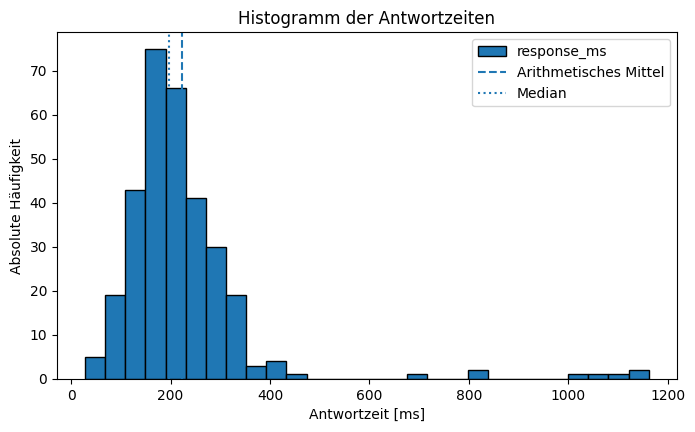

In [21]:
response_data["response_ms"].plot.hist(bins=28, edgecolor="black")
plt.axvline(response_data["response_ms"].mean(), linestyle="--", label="Arithmetisches Mittel")
plt.axvline(response_data["response_ms"].median(), linestyle=":", label="Median")
plt.title("Histogramm der Antwortzeiten")
plt.xlabel("Antwortzeit [ms]")
plt.ylabel("Absolute Häufigkeit")
plt.legend()
plt.show()

Die Verteilung ist rechtsschief. Einzelne große Antwortzeiten erhöhen das arithmetische Mittel stärker als den Median. Bei schiefen Verteilungen ist es daher sinnvoll, mehrere Lage- und Streuungsmaße gemeinsam zu betrachten.

Auch die Wahl der Klasseneinteilung eines Histogramms beeinflusst den visuellen Eindruck der Verteilung. Ein Histogramm sollte deshalb nicht isoliert interpretiert werden.

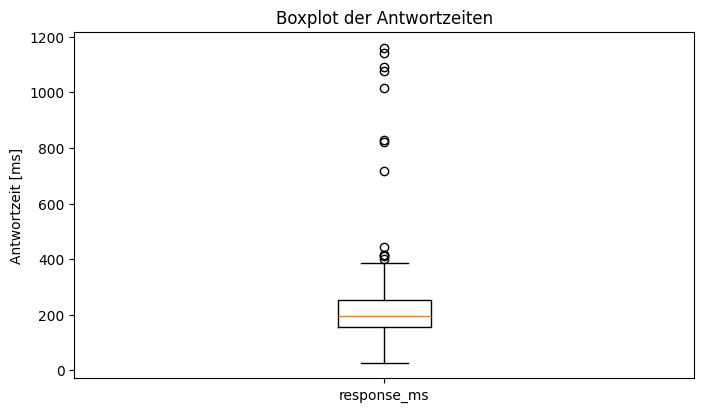

In [22]:
fig, ax = plt.subplots()
ax.bxp([boxplot_statistik(response_times, "response_ms")], showfliers=True)
ax.set_title("Boxplot der Antwortzeiten")
ax.set_ylabel("Antwortzeit [ms]")
plt.show()

### Boxplot

Der Boxplot gibt einen visuellen Eindruck von Lage und Streuung eines Datenvektors.

- Die Box beginnt beim **unteren Quartil** \(q_x(0{,}25)\) und endet beim **oberen Quartil** \(q_x(0{,}75)\).
- Die Linie innerhalb der Box kennzeichnet den Median.
- Die Länge der Box ist der Interquartilsabstand
  \[
  IQR_x=q_x(0{,}75)-q_x(0{,}25).
  \]
- Als **Ausreißer** gelten im Boxplot Datenwerte, die unterhalb von
  \[
  q_x(0{,}25)-1{,}5\cdot IQR_x
  \]
  oder oberhalb von
  \[
  q_x(0{,}75)+1{,}5\cdot IQR_x
  \]
  liegen.
- Die Whisker reichen vom kleinsten bis zum größten Wert, der nach dieser Regel nicht als Ausreißer gilt.

Die Bezeichnung als Ausreißer bedeutet nicht, dass die betreffende Beobachtung fehlerhaft sein muss.

## 8. Gruppenvergleich: Endpoint und Antwortzeit

Nun wird ein nominalskaliertes Merkmal (`endpoint`) gemeinsam mit einem metrisch skalierten Merkmal (`response_ms`) betrachtet.

In [23]:
endpoint_stats = (
    response_data.groupby("endpoint")["response_ms"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median")
    .round(1)
)

endpoint_stats

,count,mean,median,std
endpoint,,,,
/login,53,166.1,148.6,147.7
/product,78,229.6,189.5,174.6
/search,88,201.8,197.1,59.3
/cart,53,250.5,207.2,197.8
/checkout,42,299.0,296.1,64.0


In der Tabelle stehen `mean` für das arithmetische Mittel und `std` für die empirische Standardabweichung.

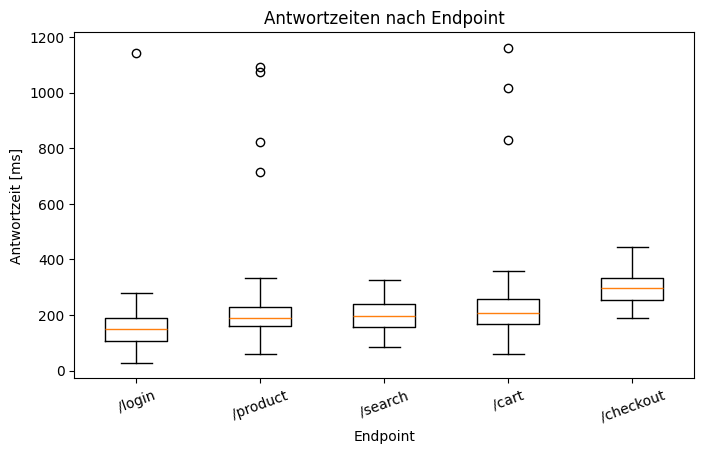

In [24]:
endpoint_order = endpoint_stats.index.to_list()

stats = [
    boxplot_statistik(
        response_data.loc[response_data["endpoint"] == endpoint, "response_ms"],
        endpoint
    )
    for endpoint in endpoint_order
]

fig, ax = plt.subplots()
ax.bxp(stats, showfliers=True)
ax.set_title("Antwortzeiten nach Endpoint")
ax.set_xlabel("Endpoint")
ax.set_ylabel("Antwortzeit [ms]")
plt.xticks(rotation=20)
plt.show()

### Fragen zur Auswertung

- Welcher Endpoint hat den größten Median der Antwortzeit?
- Bei welchem Endpoint ist die Streuung besonders groß?
- Bei welchen Endpoints treten Ausreißer im Sinne der Boxplot-Regel auf?
- Unterscheiden sich arithmetisches Mittel und Median innerhalb der Gruppen deutlich?

Die Gruppenunterschiede sind zunächst deskriptive Befunde. Aus ihnen folgt noch keine Aussage über die Ursachen der Unterschiede.

## 9. Antwortzeit und Cache-Hit

Untersuchen Sie, ob sich die beobachteten Antwortzeiten zwischen Requests mit und ohne Cache-Hit unterscheiden.

Bestimmen Sie für beide Gruppen

- die Anzahl der Beobachtungen,
- das arithmetische Mittel und
- den Median der Antwortzeit.

In [25]:
cache_stats = (
    response_data.groupby("cache_hit")["response_ms"]
    .agg(["count", "mean", "median"])
    .round(1)
)
cache_stats

,count,mean,median
cache_hit,,,
False,181,250.4,221.3
True,133,187.8,172.4


Die Gruppe mit Cache-Hit weist in diesen Daten kleinere Lagewerte auf. Das ist eine deskriptive Aussage über die vorliegenden Beobachtungen.

Für eine kausale Interpretation müsste berücksichtigt werden, dass weitere Merkmale mit dem Cache-Hit und der Antwortzeit zusammenhängen können. Mögliche Drittvariablen sind beispielsweise Endpoint, Region, Payload-Größe oder Tageszeit.

In [26]:
pd.crosstab(df["endpoint"], df["cache_hit"], normalize="index").round(2)

cache_hit,False,True
endpoint,,
/cart,0.70,0.30
/checkout,0.89,0.11
/login,0.85,0.15
/product,0.36,0.64
/search,0.38,0.62


Die Cache-Hit-Anteile unterscheiden sich zwischen den Endpoints. Ein einfacher Vergleich der Cache-Gruppen reicht deshalb nicht aus, um die kausale Wirkung des Cachings zu bestimmen.

## 10. Zwei metrisch skalierte Merkmale: Streudiagramm und Korrelation

Wir untersuchen den Zusammenhang zwischen Payload-Größe und Antwortzeit. Zunächst wird ein Streudiagramm betrachtet.

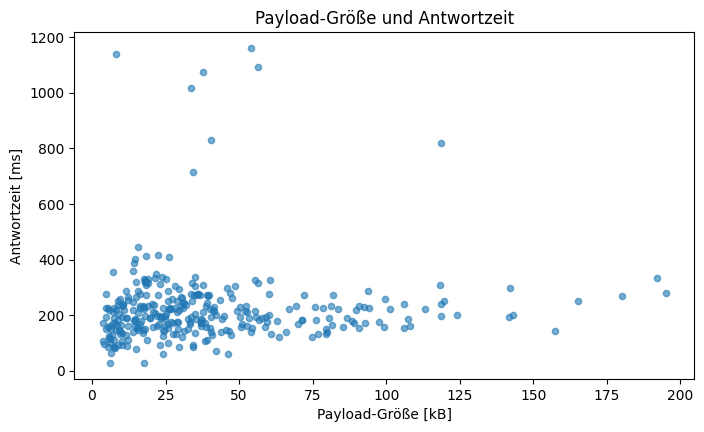

In [27]:
response_data.plot.scatter(x="payload_kb", y="response_ms", alpha=0.6)
plt.title("Payload-Größe und Antwortzeit")
plt.xlabel("Payload-Größe [kB]")
plt.ylabel("Antwortzeit [ms]")
plt.show()

In [28]:
r_xy = response_data["payload_kb"].corr(response_data["response_ms"])
print("Pearson-Korrelationskoeffizient r_x,y:", round(r_xy, 3))

Pearson-Korrelationskoeffizient r_x,y: 0.072


Der **Pearson-Korrelationskoeffizient**

\[
r_{x,y}=\frac{s_{x,y}}{s_xs_y}
\]

ist ein Maß für die lineare Korrelation zweier metrisch skalierter Merkmale. Es gilt

\[
-1\le r_{x,y}\le 1.
\]

- \(r_{x,y}=1\): perfekter positiver linearer Zusammenhang,
- \(r_{x,y}=-1\): perfekter negativer linearer Zusammenhang,
- \(r_{x,y}=0\): die beiden Merkmale sind im Sinne des Pearson-Korrelationskoeffizienten **linear unkorreliert**.

Für die Einteilung in „schwach“, „mittel“ oder „stark“ gibt es keine allgemein gültigen Grenzwerte.

Ein Korrelationskoeffizient nahe null schließt einen nichtlinearen Zusammenhang oder unterschiedliche Zusammenhänge in Teilgruppen nicht aus. Außerdem können einzelne extreme Beobachtungen den Korrelationskoeffizienten beeinflussen.

Aus einer Korrelation allein folgt keine kausale Beziehung.

Im vorliegenden Datensatz ist der lineare Gesamtzusammenhang zwischen Payload-Größe und Antwortzeit gering. Das Ergebnis schließt nicht aus, dass innerhalb einzelner Teilgruppen andere Zusammenhänge bestehen oder weitere Merkmale die Antwortzeit beeinflussen.

In [29]:
# Optional: Pearson-Korrelationskoeffizient getrennt nach Endpoint
endpoint_corr = pd.Series({
    endpoint: group["payload_kb"].corr(group["response_ms"])
    for endpoint, group in response_data.groupby("endpoint")
}, name="r_x,y")

endpoint_corr.round(2).sort_values()

/login      -0.04
/product     0.01
/checkout    0.21
/search      0.28
/cart        0.50
Name: r_x,y, dtype: float64

Die gruppenweisen Koeffizienten können sich vom Gesamtkorrelationskoeffizienten unterscheiden. Diese Auswertung kann als Hinweis darauf dienen, dass eine aggregierte Kennzahl Strukturen in Teilgruppen verdecken kann.

## 11. Zufällige Stichproben und Stichprobenmittelwerte

Für die folgende Simulation werden die Requests mit gemessener Antwortzeit als endliche Grundgesamtheit aufgefasst. Aus dieser Grundgesamtheit werden wiederholt einfache Zufallsstichproben ohne Zurücklegen gezogen.

Für jede Stichprobe mit Umfang \(n=30\) wird das arithmetische Mittel der Antwortzeiten berechnet.

In [30]:
rng = np.random.default_rng(42)

sample_means = []
for _ in range(500):
    sample = response_data["response_ms"].sample(
        n=30,
        replace=False,
        random_state=int(rng.integers(1_000_000))
    )
    sample_means.append(sample.mean())

sample_means = pd.Series(sample_means)
sample_means.describe()

count    500.000000
mean     223.541060
std       25.460108
min      162.013333
25%      204.982500
50%      219.625000
75%      238.046667
max      321.330000
dtype: float64

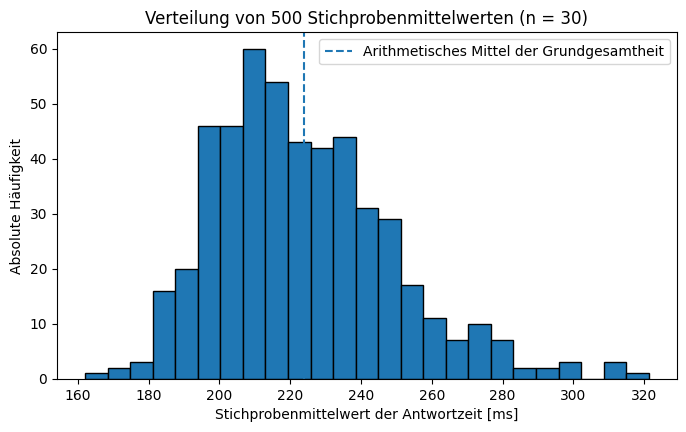

In [31]:
sample_means.plot.hist(bins=25, edgecolor="black")
plt.axvline(
    response_data["response_ms"].mean(),
    linestyle="--",
    label="Arithmetisches Mittel der Grundgesamtheit"
)
plt.title("Verteilung von 500 Stichprobenmittelwerten (n = 30)")
plt.xlabel("Stichprobenmittelwert der Antwortzeit [ms]")
plt.ylabel("Absolute Häufigkeit")
plt.legend()
plt.show()

Die Stichprobenmittelwerte sind nicht identisch, obwohl alle Stichproben aus derselben Grundgesamtheit gezogen werden. Die Stichprobenmittelwerte unterliegen also einer **zufälligen Schwankung**.

In [32]:
def repeated_means(n, repetitions=500, seed=123):
    local_rng = np.random.default_rng(seed)
    means = []
    for _ in range(repetitions):
        sample = response_data["response_ms"].sample(
            n=n,
            replace=False,
            random_state=int(local_rng.integers(1_000_000))
        )
        means.append(sample.mean())
    return pd.Series(means)

comparison = pd.DataFrame({
    "n=10": repeated_means(10),
    "n=30": repeated_means(30),
    "n=100": repeated_means(100),
})

comparison.std().round(1)

n=10     43.7
n=30     23.5
n=100    11.6
dtype: float64

In dieser Simulation nimmt die Standardabweichung der Stichprobenmittelwerte mit zunehmendem Stichprobenumfang ab. Größere Zufallsstichproben liefern daher im Allgemeinen präzisere Schätzungen eines Mittelwerts, sofern das Stichprobenverfahren und die zugrunde liegenden Annahmen angemessen sind.

## 12. Abschlussaufgaben

Beantworten Sie die folgenden Fragen zunächst mit Python und formulieren Sie anschließend jeweils eine kurze statistische Aussage.

1. Welcher Endpoint hat den größten Median der Antwortzeit?
2. Wie groß ist der relative Anteil der Requests mit Statuscode 500?
3. Welche Region hat den größten Median der Antwortzeit?
4. Formulieren Sie zu Aufgabe 3 eine rein deskriptive Aussage, ohne eine Ursache für den Unterschied zu behaupten.

In [33]:
median_by_endpoint = (
    response_data.groupby("endpoint")["response_ms"]
    .median()
    .sort_values(ascending=False)
)
median_by_endpoint

endpoint
/checkout    296.10
/cart        207.20
/search      197.15
/product     189.50
/login       148.60
Name: response_ms, dtype: float64

In [34]:
rel_freq_500 = df["status_code"].eq(500).mean() * 100
print(f"Relative Häufigkeit HTTP 500: {rel_freq_500:.1f} %")

Relative Häufigkeit HTTP 500: 4.1 %


In [35]:
median_by_region = (
    response_data.groupby("region")["response_ms"]
    .median()
    .sort_values(ascending=False)
)
median_by_region

region
US-East       273.0
EU-West       192.7
EU-Central    172.0
Name: response_ms, dtype: float64

Eine sachlich korrekte Formulierung zu Aufgabe 3 lautet beispielsweise:

> Unter den beobachteten Requests mit gemessener Antwortzeit weist die Region `US-East` den größten Median der Antwortzeit auf.

Aus dieser deskriptiven Auswertung folgt nicht, dass die Region die höheren Antwortzeiten verursacht.

### Beurteilung statistischer Aussagen

A ist durch die deskriptive Auswertung gerechtfertigt.

B ist nicht gerechtfertigt. Für eine kausale Interpretation reicht der einfache Gruppenvergleich nicht aus.

C ist nicht gerechtfertigt. Ein Pearson-Korrelationskoeffizient nahe null bedeutet lediglich, dass kein ausgeprägter linearer Gesamtzusammenhang vorliegt.

## 13. Zusammenfassung

- Die Vektor- und Summennotation aus Vorlesung 0 lässt sich unmittelbar mit Python-Berechnungen verbinden.
- Zu Beginn einer statistischen Untersuchung werden Grundgesamtheit, Merkmale, Ausprägungen und Wertemengen festgelegt.
- Merkmale können nominal, ordinal oder metrisch skaliert sein und diskret oder stetig modelliert werden.
- Absolute und relative Häufigkeiten beschreiben die Häufigkeitsverteilung diskreter Merkmale.
- Arithmetisches Mittel und Median sind Lagemaße mit unterschiedlichen Eigenschaften.
- Empirische Standardabweichung und Interquartilsabstand sind Streuungsmaße.
- Histogramm und Boxplot veranschaulichen die Verteilung metrischer Merkmale.
- Der Pearson-Korrelationskoeffizient \(r_{x,y}\) beschreibt die lineare Korrelation zweier metrischer Merkmale.
- Aus einem beobachteten Zusammenhang folgt nicht ohne Weiteres eine kausale Beziehung.
- Arithmetische Mittel verschiedener Zufallsstichproben unterliegen zufälligen Schwankungen.

# Hinweise zur Durchführung

## Zeitlicher Ablauf für etwa 75 bis 90 Minuten

| Zeit | Inhalt |
|---:|---|
| 0–8 min | Anknüpfung an Vorlesung 0: Vektor, Indizierung, Summenzeichen |
| 8–18 min | Grundgesamtheit, Merkmale, Ausprägungen, Wertemengen und Skalierungen |
| 18–28 min | Datensatz prüfen, fehlende Werte, Filtern |
| 28–38 min | Absolute und relative Häufigkeiten, Modalwert |
| 38–55 min | Lage- und Streuungsmaße, Quantile, Histogramm, Boxplot |
| 55–68 min | Gruppenvergleich nach Endpoint und Cache-Hit |
| 68–77 min | Streudiagramm und Pearson-Korrelation |
| 77–85 min | Zufällige Schwankung von Stichprobenmittelwerten |
| verbleibende Zeit | Abschlussaufgaben und Diskussion |

## Hinweise zum Einstieg

Aus Vorlesung 0 werden nur Vektor und Summenzeichen aufgegriffen. Zahlenmengen, Intervalle und Aufrunden müssen für dieses Notebook nicht erneut behandelt werden.

Beim Quantil sollte kurz darauf hingewiesen werden, dass Statistikprogramme unterschiedliche Quantilsdefinitionen verwenden können. Die im Notebook verwendete Hilfsfunktion bildet die in der Vorlesung verwendete Definition ab.

## Geeignete Diskussionsfragen

1. Warum entspricht `x[0]` dem mathematischen Element \(x_1\)?
2. Warum ist `status_code` nominalskaliert, obwohl die Ausprägungen als Zahlen gespeichert sind?
3. Warum wird für die Endpoint-Häufigkeiten `df`, für Auswertungen der Antwortzeit aber `response_data` verwendet?
4. Sind Beobachtungen außerhalb der Boxplot-Whisker automatisch Messfehler?
5. Was ist der Unterschied zwischen der Aussage „Requests mit Cache-Hit haben geringere Antwortzeiten“ und einer kausalen Aussage über die Wirkung des Cachings?
6. Was lässt sich aus einem Pearson-Korrelationskoeffizienten nahe null ableiten, und was nicht?
7. Warum unterscheiden sich arithmetische Mittel verschiedener Zufallsstichproben aus derselben Grundgesamtheit?

Bei knapper Zeit kann die gruppenweise Korrelationsanalyse entfallen. Bei der Stichprobensimulation genügt dann der Fall \(n=30\).